In [ ]:
# Bénin Insights Challenge - Analyse Sécuritaire GDELT
**iSHEERO × DataCamp Donates · Hackathon 2026**

---
## Objectif
Analyser les événements GDELT liés au Bénin sur la période avril 2025 – avril 2026,
avec un focus sur la **dimension sécuritaire** : identifier les zones à risque, les acteurs,
les tendances temporelles et produire un **Indice de Sécurité Régionale du Bénin (ISRB)**.

## Question centrale
> *Le Bénin est-il en train de basculer vers une insécurité structurelle, ou traverse-t-il une période de turbulences temporaires ?*

## méthodologique
GDELT enregistre la **couverture médiatique** des événements, pas les événements eux-mêmes.
Nos insights reflètent à la fois la réalité sécuritaire **et** la manière dont le monde perçoit le Bénin.
Cette distinction est documentée à chaque étape.

## Usage de l'IA
Ce notebook a été développé avec l'assistance de Claude (Anthropic) pour la structuration
analytique et la génération de code. Toutes les analyses et interprétations ont été
vérifiées et validées par l'équipe.

---
**Auteurs :** Équipe 8 iSHEERO Hackathon 2026  
**Date :** Mai 2026  
**Données :** GDELT v2 — ActionGeo_CountryCode = 'BN' — avr. 2025 → avr. 2026

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

CLEAN_FILE = Path('../data/clean/gdelt_benin_clean.parquet')

QUADCLASS_LABELS = {
    1: 'Coopération Verbale',
    2: 'Coopération Matérielle',
    3: 'Conflit Verbal',
    4: 'Conflit Matériel'
}

ADM1_MAP = {
    'BN16': 'Borgou',   'BN08': 'Alibori',  'BN09': 'Atakora',
    'BN07': 'Donga',    'BN10': 'Collines', 'BN18': 'Zou',
    'BN15': 'Mono',     'BN12': 'Kouffo',   'BN11': 'Atlantique',
    'BN13': 'Oueme',    'BN14': 'Plateau'
}

print('✓ Imports OK')

✓ Imports OK


In [21]:
df = pd.read_parquet(CLEAN_FILE)
print(f'Lignes   : {len(df):,}')
print(f'Période  : {df["SQLDATE"].min().date()} → {df["SQLDATE"].max().date()}')
df.head(3)

Lignes   : 22,778
Période  : 2025-04-26 → 2026-04-26


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,year,month,week
0,1248558842,2025-06-09,202506,2025,2025.4356,BEN,COTONOU,BEN,None,None,...,BN,NaN,9.5,2.25,BN,20250609020000,https://english.news.cn/20250609/833e6be5b34f4...,2025,6,24
1,1248561281,2025-06-09,202506,2025,2025.4356,NGA,BENIN CITY,NGA,None,None,...,BN,NaN,9.5,2.25,BN,20250609023000,https://punchng.com/ndlea-intercepts-drugs-dis...,2025,6,24
2,1248560915,2025-06-09,202506,2025,2025.4356,BEN,BENIN,BEN,None,None,...,BN,NaN,9.5,2.25,BN,20250609023000,https://punchng.com/ndlea-intercepts-drugs-dis...,2025,6,24


In [22]:
df_conflict  = df[df['QuadClass'].isin([3, 4])].copy()
df_high_risk = df[df['GoldsteinScale'] < -5].copy()
total        = len(df)

print('═' * 50)
print('  VUE D\'ENSEMBLE SÉCURITAIRE')
print('═' * 50)
print(f'  Total événements        : {total:,}')
print(f'  Événements conflictuels : {len(df_conflict):,}  ({len(df_conflict)/total*100:.1f}%)')
print(f'  Haut risque (GS < -5)   : {len(df_high_risk):,}  ({len(df_high_risk)/total*100:.1f}%)')
print(f'  GoldsteinScale moyen    : {df["GoldsteinScale"].mean():.3f}')
print(f'  AvgTone moyen           : {df["AvgTone"].mean():.3f}')
print('═' * 50)

══════════════════════════════════════════════════
  VUE D'ENSEMBLE SÉCURITAIRE
══════════════════════════════════════════════════
  Total événements        : 22,778
  Événements conflictuels : 6,081  (26.7%)
  Haut risque (GS < -5)   : 2,370  (10.4%)
  GoldsteinScale moyen    : 0.501
  AvgTone moyen           : -1.612
══════════════════════════════════════════════════


gros poinst pour amrquer les  evenements 
calculer l'indice 


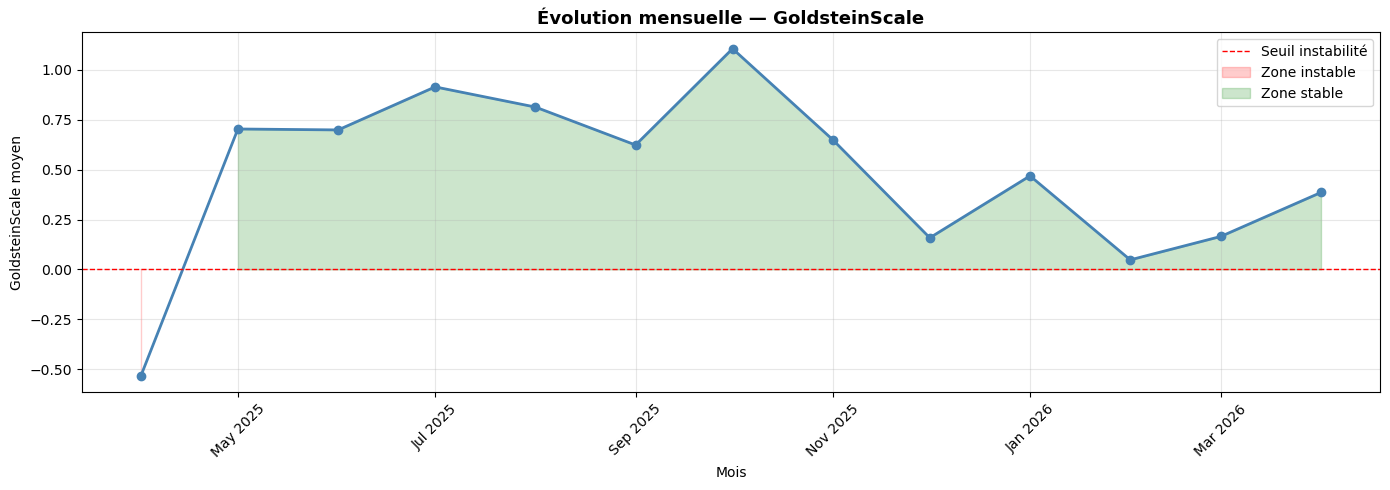

In [23]:
monthly = (
    df.groupby(df['SQLDATE'].dt.to_period('M'))['GoldsteinScale']
    .mean().reset_index()
)
monthly['SQLDATE'] = monthly['SQLDATE'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(monthly['SQLDATE'], monthly['GoldsteinScale'], marker='o', color='steelblue', linewidth=2)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Seuil instabilité')
ax.fill_between(monthly['SQLDATE'], monthly['GoldsteinScale'], 0,
                where=monthly['GoldsteinScale'] < 0, alpha=0.2, color='red', label='Zone instable')
ax.fill_between(monthly['SQLDATE'], monthly['GoldsteinScale'], 0,
                where=monthly['GoldsteinScale'] >= 0, alpha=0.2, color='green', label='Zone stable')
ax.set_title('Évolution mensuelle — GoldsteinScale', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('GoldsteinScale moyen')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../data/clean/goldstein_mensuel.png', dpi=150)
plt.show()

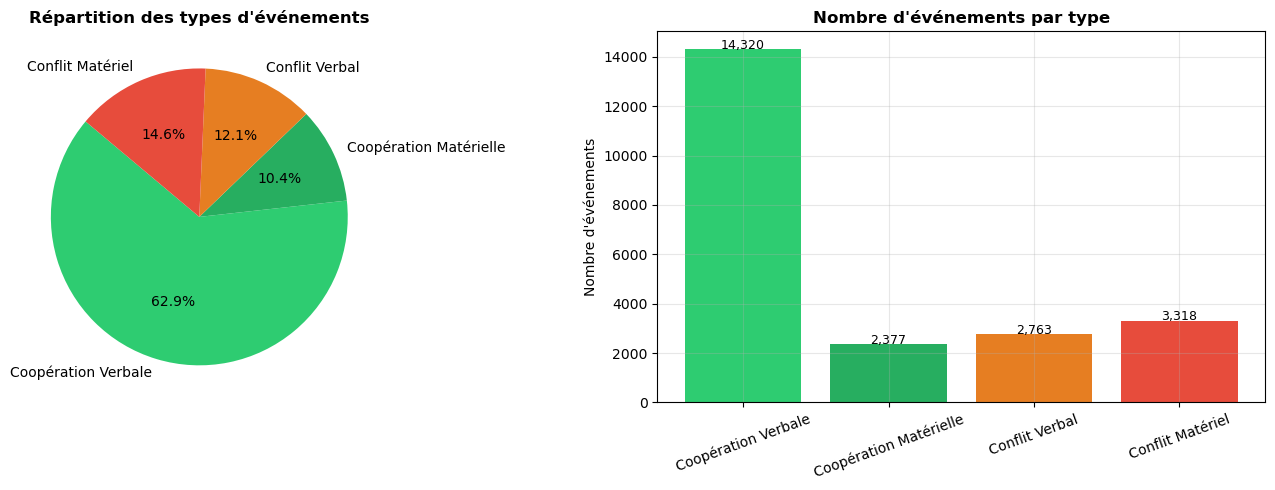

In [24]:
qc = df['QuadClass'].value_counts().sort_index()
qc.index = [QUADCLASS_LABELS.get(i, str(i)) for i in qc.index]
colors = ['#2ecc71', '#27ae60', '#e67e22', '#e74c3c']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie(qc, labels=qc.index, autopct='%1.1f%%', colors=colors, startangle=140)
ax1.set_title('Répartition des types d\'événements', fontweight='bold')
bars = ax2.bar(qc.index, qc.values, color=colors)
ax2.set_title('Nombre d\'événements par type', fontweight='bold')
ax2.set_ylabel('Nombre d\'événements')
plt.xticks(rotation=20)
for bar, val in zip(bars, qc.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/clean/quadclass_repartition.png', dpi=150)
plt.show()

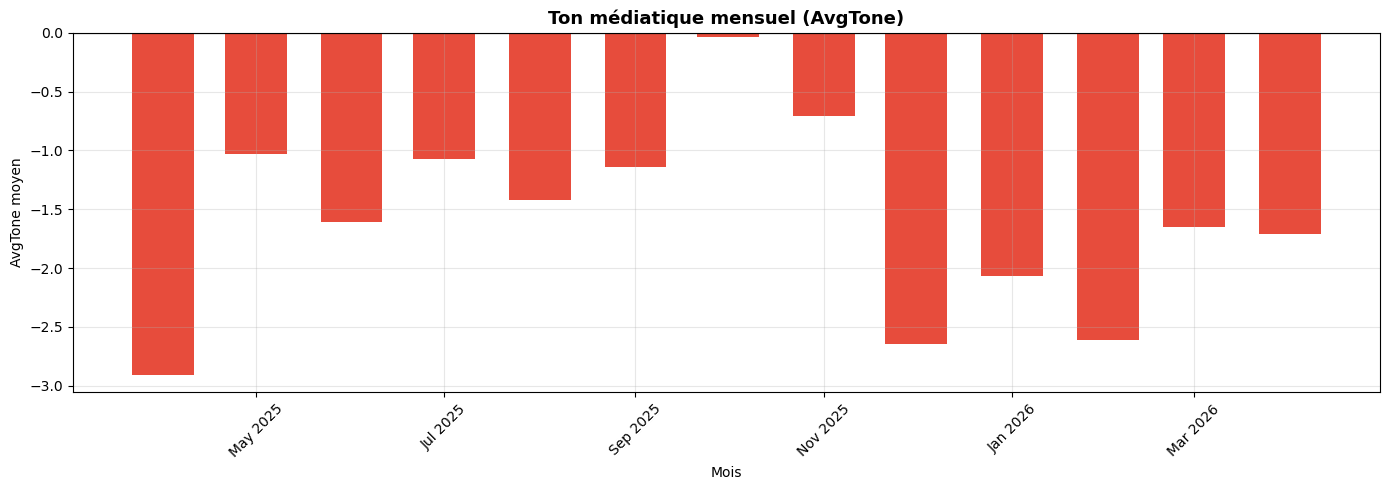

In [25]:
monthly_tone = (
    df.groupby(df['SQLDATE'].dt.to_period('M'))['AvgTone']
    .mean().reset_index()
)
monthly_tone['SQLDATE'] = monthly_tone['SQLDATE'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.bar(monthly_tone['SQLDATE'], monthly_tone['AvgTone'],
       color=['#e74c3c' if v < 0 else '#2ecc71' for v in monthly_tone['AvgTone']], width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Ton médiatique mensuel (AvgTone)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('AvgTone moyen')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/clean/avgtone_mensuel.png', dpi=150)
plt.show()

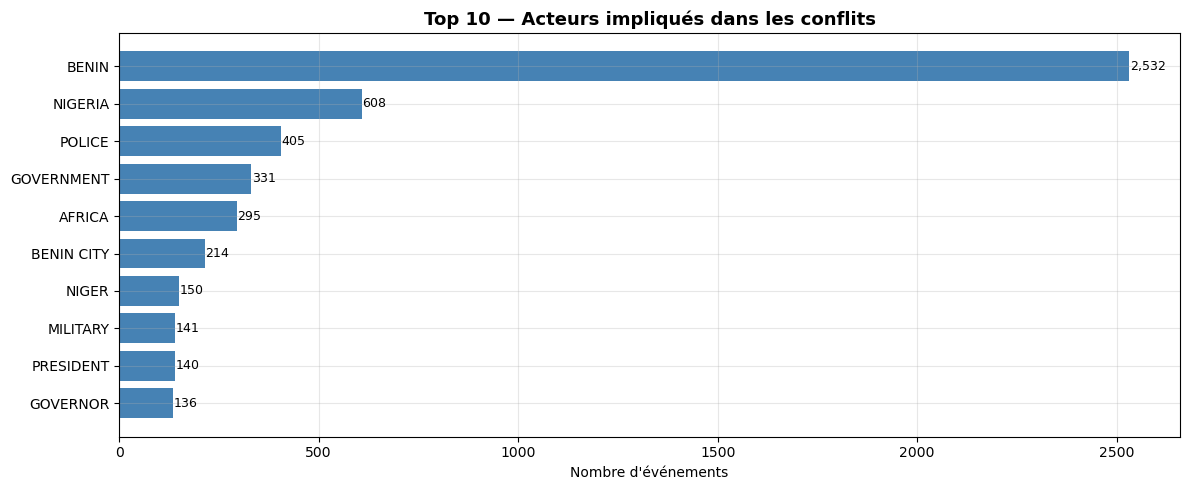

In [26]:
actors = pd.concat([df_conflict['Actor1Name'], df_conflict['Actor2Name']]).value_counts()
actors = actors[actors.index != 'Unknown'].head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(actors.index[::-1], actors.values[::-1], color='steelblue')
ax.set_title('Top 10 — Acteurs impliqués dans les conflits', fontsize=13, fontweight='bold')
ax.set_xlabel('Nombre d\'événements')
for bar, val in zip(bars, actors.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../data/clean/top10_acteurs.png', dpi=150)
plt.show()

In [27]:
summary = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    total_evenements = ('GLOBALEVENTID', 'count'),
    conflits         = ('QuadClass', lambda x: x.isin([3,4]).sum()),
    goldstein_moy    = ('GoldsteinScale', 'mean'),
    avgtone_moy      = ('AvgTone', 'mean'),
).round(3)

summary['taux_conflit_%'] = (summary['conflits'] / summary['total_evenements'] * 100).round(1)
summary.to_csv('../data/clean/synthese_securite_mensuelle.csv')

print(summary.to_string())
print('\n✓ Synthèse sauvegardée')

         total_evenements  conflits  goldstein_moy  avgtone_moy  taux_conflit_%
SQLDATE                                                                        
2025-04               466       161         -0.533       -2.909            34.5
2025-05              1807       462          0.704       -1.026            25.6
2025-06               908       226          0.699       -1.605            24.9
2025-07              2284       524          0.915       -1.074            22.9
2025-08              1516       382          0.814       -1.420            25.2
2025-09              1630       396          0.623       -1.142            24.3
2025-10              1676       332          1.106       -0.032            19.8
2025-11              1789       423          0.650       -0.708            23.6
2025-12              4221      1339          0.158       -2.646            31.7
2026-01              1544       426          0.469       -2.065            27.6
2026-02              1730       513     

il reste  a faireuen carte a bulles ou on aura les  zones  a plus de risuques ou plus sdevents concernant al securite  , ceux  à moyen , etc...
puis ausssi collaboration materielle  inclue aussi le externe  et le interne a^s  que el interne 


voir comment rajouter el ebnin city  au  nigéria   

In [28]:
df = pd.read_parquet(CLEAN_FILE)
df['departement'] = df['ActionGeo_ADM1Code'].map(ADM1_MAP)
df['mois'] = df['SQLDATE'].dt.to_period('M')

# On garde uniquement les lignes avec un departement identifie
df_dep = df[df['departement'].notna()].copy()

total_general = len(df)
total_localise = len(df_dep)

print('=' * 50)
print('  DONNEES POUR LE CALCUL ISRB')
print('=' * 50)
print(f'  Total evenements         : {total_general:,}')
print(f'  Evenements localises     : {total_localise:,} ({total_localise/total_general*100:.1f}%)')
print(f'  Evenements non localises : {total_general - total_localise:,} (exclus du calcul)')
print('=' * 50)
print()
print('  ATTENTION : l ISRB est calcule sur seulement')
print(f'  {total_localise/total_general*100:.1f}% des donnees.')
print('  Les resultats sont indicatifs, pas representatifs.')
print('=' * 50)

  DONNEES POUR LE CALCUL ISRB
  Total evenements         : 22,778
  Evenements localises     : 1,415 (6.2%)
  Evenements non localises : 21,363 (exclus du calcul)

  ATTENTION : l ISRB est calcule sur seulement
  6.2% des donnees.
  Les resultats sont indicatifs, pas representatifs.


In [32]:
# =================================================================
# CALCUL DE L'INDICE DE STABILITÉ ET DE RISQUE (ISRB)
# Objectif : Transformer les données brutes GDELT en un score 
# composite (0 à 1) mesurant la tension sociale par département.
# =================================================================

# 1. Pré-calcul des indicateurs normalisés (Vectorisation pour la performance)
# On ramène chaque métrique sur une échelle de 0 (calme) à 1 (très dégradé)

# Fréquence des conflits matériels (Manifestations, Violences...)
df_dep['quad4'] = (df_dep['QuadClass'] == 4).astype(float)

# Intensité de l'impact (Échelle Goldstein) : on normalise la partie négative
df_dep['gold_norm'] = -df_dep['GoldsteinScale'].clip(upper=0) / 10

# Négativité du ton médiatique : on normalise par la valeur max observée (18.52)
df_dep['tone_norm'] = -df_dep['AvgTone'].clip(upper=0) / 18.52

# 2. Agrégation mensuelle par département
# On calcule la moyenne de ces indicateurs pour chaque zone et chaque période
isrb_mensuel = (
    df_dep.groupby(['departement', 'mois'])[['quad4', 'gold_norm', 'tone_norm']]
    .mean()
    # 3. Application de la formule pondérée de l'ISRB
    # Poids : 40% Conflits / 35% Intensité (Goldstein) / 25% Ton des médias
    .assign(ISRB=lambda x: (
        x['quad4'] * 0.40 + 
        x['gold_norm'] * 0.35 + 
        x['tone_norm'] * 0.25
    ).round(4))
    .reset_index()[['departement', 'mois', 'ISRB']]
)

# 4. Formatage de la date pour les visualisations (Dashboard/Time Series)
isrb_mensuel['mois'] = isrb_mensuel['mois'].dt.to_timestamp()

print(f"✓ ISRB calculé pour {isrb_mensuel['departement'].nunique()} départements sur {isrb_mensuel['mois'].nunique()} mois.")


✓ ISRB calculé pour 11 départements sur 13 mois.


In [33]:
# ISRB moyen par departement sur toute la periode
# C'est le classement global du risque par zone

isrb_moy = (
    isrb_mensuel.groupby('departement')['ISRB']
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

print('=' * 50)
print('  CLASSEMENT ISRB MOYEN PAR DEPARTEMENT')
print('=' * 50)
for dep, val in isrb_moy.items():
    if val >= 0.20:
        niveau = 'CRITIQUE'
    elif val >= 0.15:
        niveau = 'ELEVE'
    elif val >= 0.08:
        niveau = 'MODERE'
    else:
        niveau = 'FAIBLE'
    barre = '#' * int(val * 40)
    print(f'  {dep:12s} {barre:20s} {val:.3f}  [{niveau}]')
print('=' * 50)

  CLASSEMENT ISRB MOYEN PAR DEPARTEMENT
  Donga        ##########           0.250  [CRITIQUE]
  Collines     ########             0.222  [CRITIQUE]
  Alibori      ########             0.217  [CRITIQUE]
  Oueme        #####                0.136  [MODERE]
  Mono         ####                 0.101  [MODERE]
  Atakora      ###                  0.087  [MODERE]
  Atlantique   ##                   0.066  [FAIBLE]
  Zou          ##                   0.053  [FAIBLE]
  Borgou       #                    0.048  [FAIBLE]
  Plateau      #                    0.029  [FAIBLE]
  Kouffo       #                    0.028  [FAIBLE]


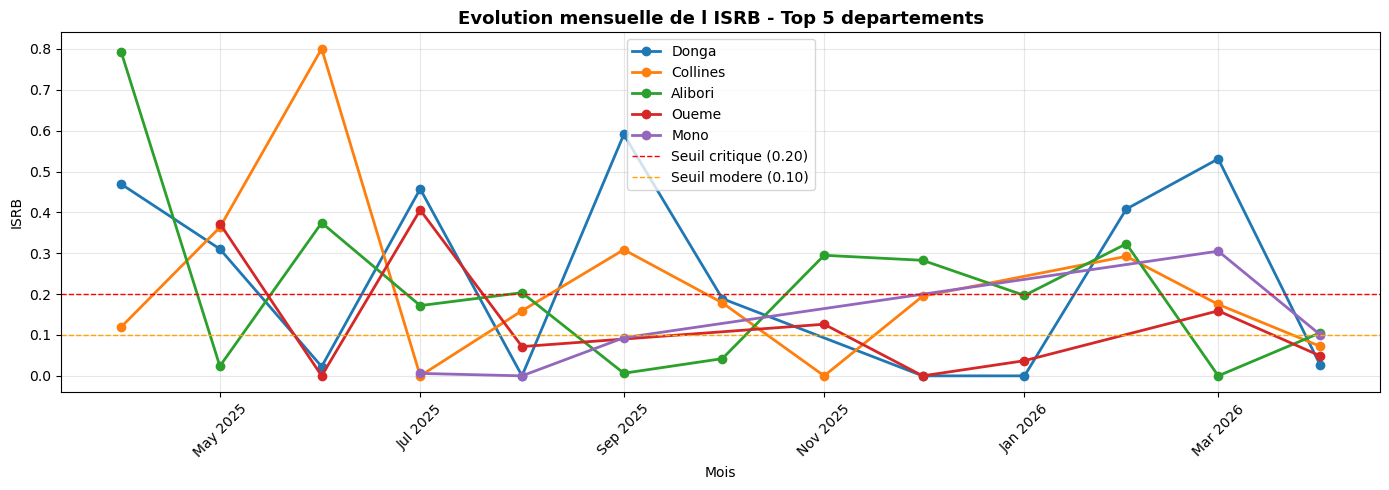

In [34]:
# Visualisation 1 : evolution ISRB par departement dans le temps
# Meme style que les graphes precedents

fig, ax = plt.subplots()

for dep in isrb_moy.index[:5]:
    data = isrb_mensuel[isrb_mensuel['departement'] == dep]
    ax.plot(data['mois'], data['ISRB'], marker='o', linewidth=2, label=dep)

ax.axhline(0.20, color='red', linestyle='--', linewidth=1, label='Seuil critique (0.20)')
ax.axhline(0.10, color='orange', linestyle='--', linewidth=1, label='Seuil modere (0.10)')
ax.set_title('Evolution mensuelle de l ISRB - Top 5 departements', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('ISRB')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../data/clean/isrb_evolution_mensuelle.png', dpi=150)
plt.show()

In [35]:
# Export des resultats
# Meme logique que la synthese mensuelle precedente

isrb_export = isrb_mensuel.copy()
isrb_export['mois'] = isrb_export['mois'].dt.strftime('%Y-%m')
isrb_export['niveau'] = isrb_export['ISRB'].apply(
    lambda v: 'Critique' if v >= 0.20 else 'Eleve' if v >= 0.15
    else 'Modere' if v >= 0.08 else 'Faible'
)
isrb_export.to_csv('../data/clean/isrb_mensuel.csv', index=False)

isrb_moy_export = isrb_moy.reset_index()
isrb_moy_export.columns = ['departement', 'isrb_moyen']
isrb_moy_export.to_csv('../data/clean/isrb_moyen_departements.csv', index=False)

# Mois le plus risque par departement
pire_mois = (
    isrb_mensuel.loc[isrb_mensuel.groupby('departement')['ISRB'].idxmax()]
    [['departement', 'mois', 'ISRB']]
    .sort_values('ISRB', ascending=False)
)
pire_mois['mois'] = pire_mois['mois'].dt.strftime('%Y-%m')

print('=' * 50)
print('  MOIS LE PLUS RISQUE PAR DEPARTEMENT')
print('=' * 50)
print(pire_mois.to_string(index=False))
print()
print('✓ isrb_mensuel.csv sauvegarde')
print('✓ isrb_moyen_departements.csv sauvegarde')

  MOIS LE PLUS RISQUE PAR DEPARTEMENT
departement    mois   ISRB
   Collines 2025-06 0.8005
    Alibori 2025-04 0.7913
      Donga 2025-09 0.5906
      Oueme 2025-07 0.4059
       Mono 2026-03 0.3051
    Atakora 2026-03 0.2887
 Atlantique 2025-05 0.2537
     Borgou 2025-08 0.1703
        Zou 2026-04 0.1617
     Kouffo 2025-09 0.1468
    Plateau 2026-04 0.0583

✓ isrb_mensuel.csv sauvegarde
✓ isrb_moyen_departements.csv sauvegarde
